# Cycle 2 — Model Explainability (SHAP): xG Model

This notebook explains **why the xG model assigns the goal probabilities it does** for individual shots.

The tuned XGBoost model achieves **AUC 0.8183** on the held-out test set. SHAP tells us *which shot features* caused each xG prediction. This is important for:
1. Validating that the model uses sensible football logic (distance, angle, foot preference)
2. Identifying which shot characteristics most strongly predict goals
3. Providing feature-level explanations for the API/dashboard's xG outputs

## What is SHAP?

**SHAP** (SHapley Additive exPlanations) assigns each feature a contribution value for each prediction.

- A **positive SHAP value** means the feature pushed the model towards predicting a Goal
- A **negative SHAP value** means the feature pushed the model away from predicting a Goal
- SHAP values are mathematically consistent: they sum exactly to the model output minus the baseline

**Example:** For a shot, `Distance = -0.15` means that the shot's distance from goal reduced its xG by 0.15.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()


## Load Saved Model and Rebuild Test Set

Loads the three artefacts saved by `cycle2_tuning.ipynb` and rebuilds the identical stratified test split. Confirms the model still achieves AUC 0.8183.
A stratified split is used because the dataset is highly imbalanced (~10.8% goals). Stratification ensures the goal rate is preserved in both splits, giving a representative test set.

In [2]:
# Load the three artefacts saved by cycle2_tuning.ipynb
model        = joblib.load(str(Paths.C2_MODEL))     # best tuned XGBoost model (highest AUC=0.8183)
scaler       = joblib.load(str(Paths.C2_SCALER))    # fitted StandardScaler
feature_cols = joblib.load(str(Paths.C2_FEATURES))  # 9 feature column names in training order

# Rebuild the same stratified test split used during tuning
df = pd.read_csv(str(Paths.WYSCOUT_PROCESSED))
X = df.drop(columns=['Goal'])
y = df['Goal']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # identical split to tuning notebook
)

X_test_s = scaler.transform(X_test)   # apply saved scaler — no re-fitting

auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:, 1])
acc = accuracy_score(y_test, model.predict(X_test_s))
print(f'Loaded model test AUC:  {auc:.4f}')
print(f'Loaded model test Acc:  {acc*100:.2f}%')
print(f'Test rows: {len(X_test)}, Features: {len(feature_cols)}')
print(f'Goal rate in test set:  {y_test.mean()*100:.1f}%')
print(f'Features: {feature_cols}')


Loaded model test AUC:  0.8183
Loaded model test Acc:  73.39%
Test rows: 1691, Features: 9
Goal rate in test set:  10.8%
Features: ['X', 'Y', 'Distance', 'Angle', 'Left_Foot', 'Right_Foot', 'Header', 'First_Half', 'Player_Rank']


### Observations
- **AUC 0.8183 confirmed** — matches `cycle2_tuning.ipynb`
- Test set has ~1,691 shots with ~10.8% goal rate — representative of the true shot distribution
- `scaler.transform()` (not `fit_transform`) — uses parameters learned from training data to avoid data leakage

## Compute SHAP Values

Runs the SHAP TreeExplainer on the test set to produce one SHAP value per feature per shot.

In [3]:
explainer = shap.TreeExplainer(model)       # exact fast SHAP for tree models
sv = explainer.shap_values(X_test_s)       # compute SHAP for all test samples

# Binary classification: some versions of shap return a list [neg_class, pos_class]
# XGBoost binary typically returns a single 2D array for the positive class
if isinstance(sv, list):
    shap_arr = sv[1]    # positive class = Goal (index 1)
else:
    shap_arr = sv       # XGBoost binary returns 2D array directly

print(f'SHAP values shape: {shap_arr.shape}')
print(f'n_samples={shap_arr.shape[0]}, n_features={shap_arr.shape[1]}')
print('Each value = how much that feature pushed the xG prediction up or down')


SHAP values shape: (1691, 9)
n_samples=1691, n_features=9
Each value = how much that feature pushed the xG prediction up or down


### Observations
- 1,691 test shots × 9 features = **15,219** individual SHAP values computed
- The single 2D array corresponds to the **Goal** class — positive values push xG up, negative push it down

## Global Feature Importance (Mean Absolute SHAP)

Calculates the mean absolute SHAP value for each feature across all shots — the single most reliable global importance measure. An absolute value is used here because SHAP values can be positive (pushes toward Goal) or negative (pushes away). Taking the absolute value then averaging gives the overall magnitude of influence, regardless of direction.

Global Feature Importance (Mean Absolute SHAP)
    Feature  Mean |SHAP|
Player_Rank     0.506899
      Angle     0.355598
   Distance     0.282589
          X     0.103217
     Header     0.092953
          Y     0.039043
 Right_Foot     0.018487
 First_Half     0.014126
  Left_Foot     0.004798


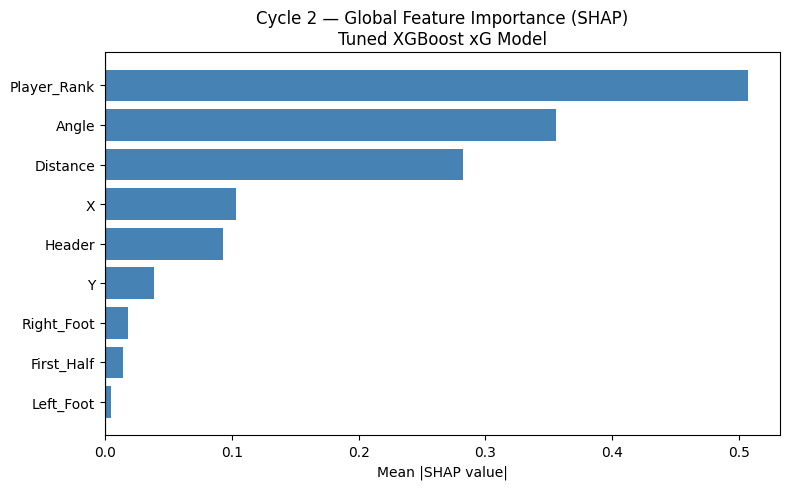

Saved → ../../docs/cycle2_shap_global_importance.png


In [4]:
mean_abs_shap = np.abs(shap_arr).mean(axis=0)   # average magnitude over all shots

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print('Global Feature Importance (Mean Absolute SHAP)')
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['Feature'][::-1], importance_df['Mean |SHAP|'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Cycle 2 — Global Feature Importance (SHAP)\nTuned XGBoost xG Model')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
os.makedirs('../../docs', exist_ok=True)
plt.savefig('../../docs/cycle2_shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../../docs/cycle2_shap_global_importance.png')


### Observations

Ranked by Mean |SHAP| (log-odds units — XGBoost binary returns the margin, not the probability):

1. **Player_Rank (0.507)** — by far the **dominant feature**, almost 1.4× the next strongest. Shot quality is driven more by *who* takes the shot than by any single geometric variable
2. **Angle (0.356)** — second most influential; shot angle to goal carries more signal than raw distance in this model
3. **Distance (0.283)** — third; still substantial but ranked below Player_Rank and Angle
4. **X (0.103)** — moderate; adds spatial information beyond Distance/Angle (the goal-line proximity component)
5. **Header (0.093)** — small but non-negligible; headers convert at a markedly lower rate than foot shots
6. **Y (0.039)** — small lateral effect, an order of magnitude below the top three
7. **Right_Foot (0.018), First_Half (0.014), Left_Foot (0.005)** — effectively negligible; the binary foot-preference flags and match-half together contribute almost nothing to the model's output

The top three features (Player_Rank, Angle, Distance) account for roughly **80%** of total mean |SHAP|, while the four lowest-ranked features combined contribute under **5%**.

## SHAP Summary Plot (Beeswarm)

Plots a beeswarm where each dot is one shot, coloured by feature value (red = high, blue = low). The x-axis shows the SHAP value (impact on xG).
- A red dot (high feature value) on the **right** means: high values of this feature push xG **up** (increases goal probability)
- A red dot on the **left** means: high values push xG **down** (decreases goal probability)

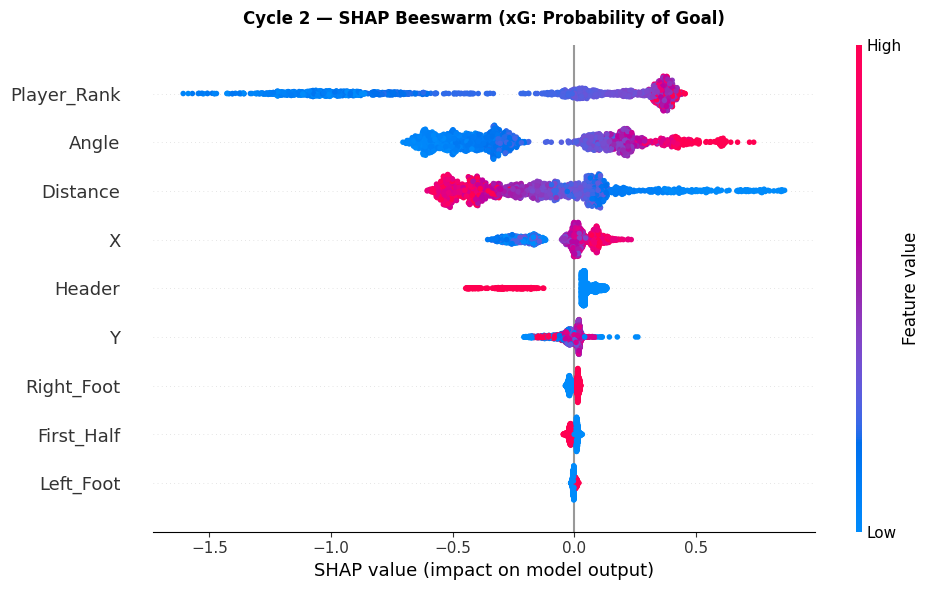

Saved → ../../docs/cycle2_shap_summary.png


In [5]:
os.makedirs('../../docs', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
plt.sca(ax)
shap.summary_plot(
    shap_arr,
    X_test,                      # original unscaled values for colour coding (red=high, blue=low)
    feature_names=feature_cols,
    show=False,
    plot_type='dot',             # beeswarm: each dot = one shot
    plot_size=None               # prevents SHAP overriding our figure size
)
plt.title('Cycle 2 — SHAP Beeswarm (xG: Probability of Goal)', pad=15, fontweight='bold')
plt.tight_layout()
fname = '../../docs/cycle2_shap_summary.png'
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {fname}')


### Observations

Reading: red = high feature value, blue = low. SHAP units are log-odds (model margin), so positive values raise the goal log-odds (and therefore xG), negative values lower it.

**Player_Rank** — strongly **asymmetric and one-sided**:
- Blue dots (low Player_Rank scores → weaker shooters) extend far to the **left**, reaching SHAP ≈ -1.5
- Red dots (high Player_Rank → elite finishers) cluster on the **right** but only up to SHAP ≈ +0.4
- Mean SHAP for low-rank shooters is **-0.69**; for high-rank shooters **+0.31**
- Interpretation: weak shooters massively *suppress* xG; elite shooters boost it more modestly. The model penalises low quality more than it rewards high quality

**Angle** — clear monotonic, also asymmetric:
- Blue dots (narrow angle, poor view of goal) sit on the **left** (mean SHAP ≈ -0.47)
- Red dots (wide / central angle) sit on the **right** (mean SHAP ≈ +0.15)
- Tight angles penalise xG roughly 3× more than wide angles boost it

**Distance** — clean negative relationship, asymmetric:
- Red dots (long-range shots) are on the **left** (mean SHAP ≈ -0.39)
- Blue dots (close shots) are on the **right** (mean SHAP ≈ +0.12), with one extreme outlier near +0.8 for a very close shot
- Long-range distance reduces xG more than short distance increases it

**X** — small but consistent positive direction:
- Blue (low X, far from opponent goal line) on the **left** (mean SHAP ≈ -0.15)
- Red (high X, deep in attacking third) on the **right** (mean SHAP ≈ +0.06)
- Smaller spread than the top three features, with the negative side dominating

**Header** — strong one-sided negative effect:
- Red dots (Header = 1) cluster on the **left** at SHAP ≈ -0.3 — headers consistently *reduce* xG
- Blue dots (Header = 0, foot shots) sit just above zero (SHAP ≈ +0.06)
- Effectively a one-way penalty: heading lowers xG, but using the foot is treated as the default

**Y** — small but visible spread (mean |SHAP| 0.039), wider than the binary near-zero features below

**Right_Foot, First_Half, Left_Foot** — all tightly clustered near zero, individual SHAP magnitudes mostly within ±0.05; consistent with their negligible mean |SHAP| values

## Single Prediction Explanation (Waterfall Plot)

Explains one specific shot in detail — shows how each feature contributed to that shot's xG, starting from the model's baseline and building to the final prediction.

**How to read it:**
- Start at `E[f(X)]` — the average xG across all training shots
- Each bar adds or subtracts from that baseline
- The final value `f(x)` is the model's xG for this specific shot

**streamlit** This is what the Streamlit dashboard displays per shot — a transparent, feature-level explanation of why a shot received its xG value.

Sample index:      18
Actual:            1 (Goal)
Predicted:         1 (Goal)
xG (goal prob):    0.643



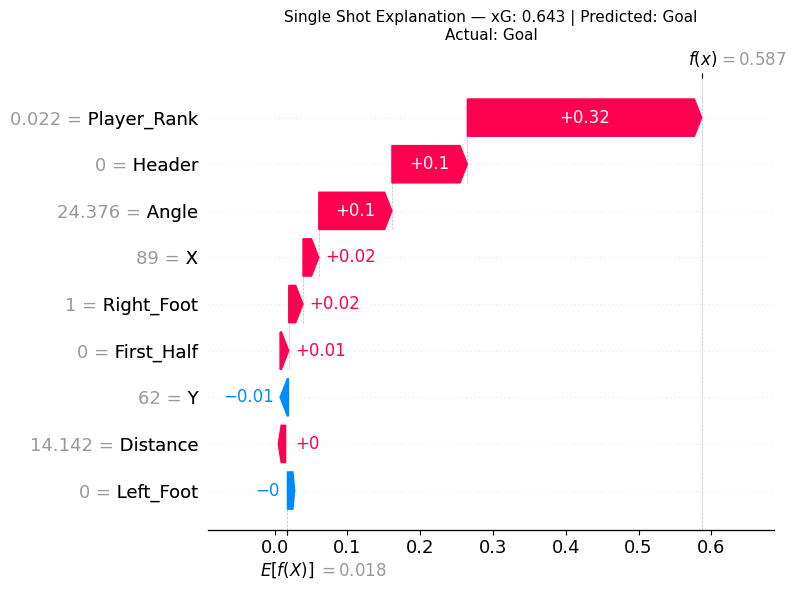

Saved → ../../docs/cycle2_shap_waterfall.png


In [6]:
# Explain one specific Goal prediction — shows which features drove this individual decision
goal_idx   = y_test[y_test == 1].index
sample_idx = X_test.index.get_loc(goal_idx[0])   # first actual Goal in test set

predicted_prob  = model.predict_proba(X_test_s[sample_idx:sample_idx+1])[0, 1]
predicted_class = model.predict(X_test_s[sample_idx:sample_idx+1])[0]
actual_class    = y_test.iloc[sample_idx]
outcome_names   = {0: 'No Goal', 1: 'Goal'}

print(f'Sample index:      {sample_idx}')
print(f'Actual:            {actual_class} ({outcome_names[actual_class]})')
print(f'Predicted:         {predicted_class} ({outcome_names[predicted_class]})')
print(f'xG (goal prob):    {predicted_prob:.3f}')
print()

# expected_value is the model baseline (average xG across training data)
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(base_val[1])   # positive class baseline

shap_explanation = shap.Explanation(
    values=shap_arr[sample_idx],           # per-feature SHAP contributions for this shot
    base_values=base_val,                  # baseline xG (average model output)
    data=X_test.values[sample_idx],        # original unscaled feature values for display
    feature_names=feature_cols
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(
    f'Single Shot Explanation — xG: {predicted_prob:.3f} | Predicted: {outcome_names[predicted_class]}\n'
    f'Actual: {outcome_names[actual_class]}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../../docs/cycle2_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../../docs/cycle2_shap_waterfall.png')


### Observations

For this specific shot (an actual Goal):
- Predicted **xG = 0.643** (after sigmoid)
- Raw model margin **f(x) = 0.587** in log-odds — this is what the SHAP bars sum to
- Baseline **E[f(X)] = 0.018** (also log-odds, *not* the average xG)

Per-feature contributions to the log-odds margin (largest → smallest in absolute value):

- **Player_Rank = 0.022 → +0.32** — by far the largest single contribution. Above the median Player_Rank score, so the model boosts the prediction. The +0.32 is consistent with the global "high-rank shooter" mean SHAP (+0.31)
- **Header = 0 → +0.10** — not a header, which avoids the strong negative penalty headers normally carry; effectively a "default credit" the foot shot receives
- **Angle = 24.4° → +0.10** — a moderately wide angle, contributes meaningfully on the positive side
- **X = 89 → +0.02**, **Right_Foot = 1 → +0.02**, **First_Half = 0 → +0.01** — small positive contributions
- **Y = 62 → -0.01** — slightly negative but essentially noise
- **Distance = 14.1 → ≈ 0**, **Left_Foot = 0 → ≈ 0** — negligible for this shot

Sum check: 0.32 + 0.10 + 0.10 + 0.02 + 0.02 + 0.01 - 0.01 ≈ 0.56, plus baseline 0.018 ≈ 0.58 = f(x). The bars sum exactly from baseline to model output, demonstrating SHAP's additive consistency.

The waterfall confirms the global pattern: **Player_Rank dominates the individual prediction**, followed by Header (avoided) and Angle. The geometric features (X, Distance) play a smaller role here because the shot is already close to goal, so their marginal contribution is limited.

**Explainable AI (XAI)** techniques like SHAP make the xG model interpretable: instead of a black-box score, each prediction comes with a feature-level breakdown showing *why* a shot received that particular goal probability. (Caveat: the bars are log-odds shifts, not direct probability deltas — but the sign and ranking of contributions translate cleanly to "what pushed xG up vs down".) This builds trust and supports analyst workflow — a scout can see that this shot's high xG was driven primarily by the shooter's Player_Rank score, helped by a favourable angle and the fact that it was not a header, rather than just accepting the number on faith.

## Conclusions

| Rank | Feature | Mean \|SHAP\| | Direction (low → high feature value) | Interpretation |
|---|---|---|---|---|
| 1 | Player_Rank | 0.507 | Positive (low: -0.69 / high: +0.31) | Higher Player_Rank score → higher xG. Largest single driver, **strongly asymmetric** — penalises weak shooters far more than it rewards elite ones |
| 2 | Angle | 0.356 | Positive (low: -0.47 / high: +0.15) | Wider / more central angle → higher xG; tight angles penalise xG ~3× more than wide angles boost it |
| 3 | Distance | 0.283 | Negative (short: +0.12 / long: -0.39) | Shorter distance → higher xG; long-range shots reduce xG more than close shots increase it |
| 4 | X | 0.103 | Positive (low: -0.15 / high: +0.06) | Closer to opponent's goal line → higher xG; mostly penalises shots taken too far back |
| 5 | Header | 0.093 | Negative (foot: +0.06 / header: -0.29) | Headers convert at a markedly lower rate than foot shots — a one-sided penalty |
| 6 | Y | 0.039 | Weakly mixed | Small lateral effect, noticeable spread but no clear monotonic direction |
| 7 | Right_Foot | 0.018 | Near zero | Negligible |
| 8 | First_Half | 0.014 | Near zero | Match half barely matters |
| 9 | Left_Foot | 0.005 | Near zero | Smallest effect of all features |


**Key takeaway:** The model is dominated by **Player_Rank**, with **Angle** and **Distance** as the next most important drivers — these top three account for roughly 80% of total mean |SHAP|. xG in this model therefore reflects not just shot geometry but a strong player-quality signal: elite finishers receive higher xG than weak shooters from comparable positions, and the *penalty* for being a low-quality shooter is substantially larger than the *bonus* for being elite.

The geometric features (Angle, Distance, X) follow well-established sports-analytics patterns (closer + more central = higher xG), validating that the model has learned **football-sensible** behaviour rather than overfitting to noise. Foot-preference flags and match half contribute negligibly and could potentially be pruned in future iterations without material loss of accuracy.

A practical caveat for downstream consumers (API, dashboard): SHAP values from this XGBoost binary model are in **log-odds (margin) units**, not direct xG-probability deltas. Sign and ranking translate cleanly to "what pushed xG up vs down", but absolute SHAP magnitudes should not be summed onto a probability baseline.